# Transformações numéricas

**Tema:** Preparação de Dados › Feature Engineering

Log, potência, binning, razões e interações — cada transformação resolve um
problema específico. Este notebook mostra o "antes e depois" de cada uma
aplicada a um dataset sintético de crédito, e mede o efeito real sobre um
modelo, não só sobre a forma da distribuição.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer, StandardScaler

rng = np.random.default_rng(30)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Log: comprimindo a assimetria

`renda` tem cauda longa clássica. `np.log1p` lida com zeros com segurança.

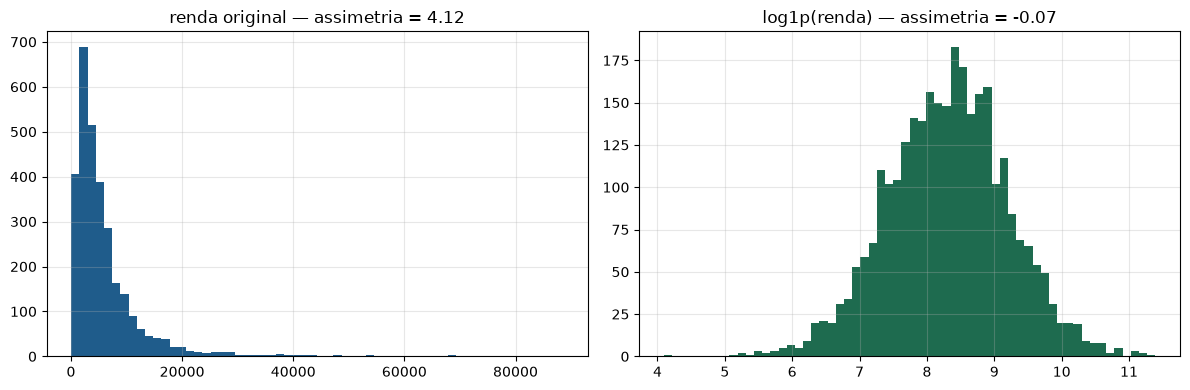

In [2]:
n = 3000
renda = rng.lognormal(np.log(4000), 0.9, n)
renda_log = np.log1p(renda)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(renda, bins=60, color=AZUL)
axes[0].set_title(f"renda original — assimetria = {stats.skew(renda):.2f}")
axes[1].hist(renda_log, bins=60, color=VERDE)
axes[1].set_title(f"log1p(renda) — assimetria = {stats.skew(renda_log):.2f}")
plt.tight_layout(); plt.show()

## 2. Interações: quando um modelo linear precisa de ajuda explícita

Construímos um alvo cuja probabilidade depende do **produto** de duas
variáveis (uma interação real). Um modelo linear sem o termo de interação
não consegue capturar esse padrão; com o termo, consegue.

In [3]:
n = 4000
tempo_de_casa = rng.uniform(0, 10, n)
engajamento = rng.uniform(0, 10, n)

# a probabilidade de churn depende do PRODUTO: só é baixa quando os dois são altos
logit = -3 + 0.6 * tempo_de_casa * engajamento / 10 - 0.3 * tempo_de_casa - 0.3 * engajamento
prob_churn = 1 / (1 + np.exp(-logit))
churn = (rng.random(n) < prob_churn).astype(int)

X_sem_interacao = np.column_stack([tempo_de_casa, engajamento])
X_com_interacao = np.column_stack([tempo_de_casa, engajamento, tempo_de_casa * engajamento])

modelo_sem = LogisticRegression()
modelo_com = LogisticRegression()

auc_sem = cross_val_score(modelo_sem, X_sem_interacao, churn, cv=5, scoring="roc_auc").mean()
auc_com = cross_val_score(modelo_com, X_com_interacao, churn, cv=5, scoring="roc_auc").mean()

print(f"AUC SEM termo de interação: {auc_sem:.4f}")
print(f"AUC COM termo de interação: {auc_com:.4f}")
print(f"\nganho: {auc_com - auc_sem:+.4f}")

AUC SEM termo de interação: 0.5441
AUC COM termo de interação: 0.6121

ganho: +0.0680


**O modelo linear não descobre a interação sozinho.** Uma árvore de decisão
(tema 4) conseguiria aproximar esse padrão via splits sucessivos — mas um
modelo linear precisa que o termo `tempo_de_casa * engajamento` exista
explicitamente como coluna.

## 3. `PolynomialFeatures`: útil com moderação, perigoso em massa

In [4]:
n_features_originais = 15
X_muitas_features = rng.normal(size=(500, n_features_originais))

poly = PolynomialFeatures(degree=2, include_bias=False)
X_expandido = poly.fit_transform(X_muitas_features)

print(f"features originais: {n_features_originais}")
print(f"features após grau 2 (todas as interações + quadrados): {X_expandido.shape[1]}")
print(f"crescimento: {X_expandido.shape[1] / n_features_originais:.1f}x")

for p in [5, 15, 30, 50]:
    n_gerado = PolynomialFeatures(degree=2, include_bias=False).fit_transform(
        rng.normal(size=(10, p))).shape[1]
    print(f"  {p:>3d} features originais -> {n_gerado:>4d} após grau 2")

features originais: 15
features após grau 2 (todas as interações + quadrados): 135
crescimento: 9.0x
    5 features originais ->   20 após grau 2
   15 features originais ->  135 após grau 2
   30 features originais ->  495 após grau 2
   50 features originais -> 1325 após grau 2


Com 50 features originais, o grau 2 gera mais de 1.300 colunas — a maioria
sem relação real com o alvo, e com forte potencial de multicolinearidade
entre si (o próprio $x_1$ e $x_1^2$ já são correlacionados). Use
`PolynomialFeatures` em subconjuntos pequenos e escolhidos, não no dataset
inteiro.

## 4. Binning: quando ajuda um modelo linear e quando atrapalha uma árvore

In [5]:
n = 2000
idade = rng.uniform(18, 70, n)
# relação em U com a idade: risco alto em jovens E em idosos, baixo no meio
risco_logit = 0.08 * (idade - 42) ** 2 / 20 - 2.5
prob_risco = 1 / (1 + np.exp(-risco_logit))
inadimplente = (rng.random(n) < prob_risco).astype(int)

# discretizando idade em 5 faixas de igual frequência
discretizador = KBinsDiscretizer(n_bins=5, encode="onehot-dense", strategy="quantile")
idade_discretizada = discretizador.fit_transform(idade.reshape(-1, 1))

from sklearn.tree import DecisionTreeClassifier

modelos = {
    "linear, idade CONTÍNUA": (LogisticRegression(), idade.reshape(-1, 1)),
    "linear, idade DISCRETIZADA": (LogisticRegression(max_iter=1000), idade_discretizada),
    "árvore, idade CONTÍNUA": (DecisionTreeClassifier(max_depth=4, random_state=0),
                              idade.reshape(-1, 1)),
}

print(f"{'modelo':<32s} {'AUC (5-fold)':>14s}")
print("-" * 48)
for nome, (modelo, X) in modelos.items():
    auc = cross_val_score(modelo, X, inadimplente, cv=5, scoring="roc_auc").mean()
    print(f"{nome:<32s} {auc:>14.4f}")

modelo                             AUC (5-fold)
------------------------------------------------
linear, idade CONTÍNUA                   0.5617
linear, idade DISCRETIZADA               0.7160


árvore, idade CONTÍNUA                   0.7129


**Leitura esperada:** o modelo linear com idade contínua tem desempenho
ruim (uma reta não representa uma relação em U). Discretizar resolve isso
para o modelo linear — cada faixa vira um coeficiente independente,
aproximando a forma em U por um "degrau". A árvore já lida bem com a relação
em U usando a idade contínua diretamente — discretizar antes normalmente não
ajudaria, e poderia até atrapalhar ao perder granularidade.

## 5. Razões de negócio: cuidado com divisão por (quase) zero

In [6]:
receita = rng.uniform(1000, 500000, 300)
n_funcionarios = rng.integers(0, 50, 300)  # ALGUMAS empresas com 0 funcionários registrados

with np.errstate(divide="ignore", invalid="ignore"):
    produtividade_ingenua = receita / n_funcionarios

n_infinitos = np.isinf(produtividade_ingenua).sum()
print(f"valores infinitos/indefinidos gerados: {n_infinitos}")

# correção: usar um piso mínimo (ex.: sócio-proprietário conta como 1)
produtividade_corrigida = receita / np.clip(n_funcionarios, 1, None)
print(f"após clip mínimo de 1 funcionário: "
      f"{np.isinf(produtividade_corrigida).sum()} infinitos")

valores infinitos/indefinidos gerados: 6
após clip mínimo de 1 funcionário: 0 infinitos


## O que levar deste notebook

- Log (com `log1p` para lidar com zero) é a transformação padrão para
  comprimir cauda longa — mede-se pelo efeito na assimetria, não por regra
  fixa.
- Interações precisam ser criadas explicitamente para modelos lineares;
  árvores e boosting capturam boa parte delas implicitamente.
- `PolynomialFeatures` em massa cresce quadraticamente e produz
  multicolinearidade — use com um subconjunto pequeno e intencional de
  features.
- Binning ajuda modelos lineares a capturar relações não-monotônicas; raramente
  ajuda árvores, que já encontram os cortes ótimos sozinhas.
- Razões de negócio exigem tratamento explícito de divisão por zero antes de
  qualquer modelo ver o resultado.

→ Próximo: **Features temporais e agregações**, e o cuidado redobrado contra
vazamento que elas exigem.